In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import exposure # Para CLAHE en color
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, closing, disk
from skimage.measure import label, regionprops

In [8]:
params_set1 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 230,        # Mucho más alto
    "dark_thresh_factor": 0.95,  # Menos sensible a oscuros
    "low_sat_thresh": 40,        # Solo colores muy desaturados
    "very_dark_val_thresh": 50,  # Solo valores muy bajos
    "line_threshold": 80,        # Solo líneas muy marcadas
    "opening_disk_radius": 3,    # Más limpieza
    "closing_disk_radius": 6,    # Más conexión
    "min_size_noise": 200        # Solo daños grandes
}
params_set2 = {
    "clahe_clip_limit": 1.8,
    "bright_thresh": 225,
    "dark_thresh_factor": 1.0,
    "low_sat_thresh": 35,
    "very_dark_val_thresh": 60,
    "line_threshold": 90,
    "opening_disk_radius": 4,
    "closing_disk_radius": 7,
    "min_size_noise": 250
}
params_set3 = {
    "clahe_clip_limit": 2.2,
    "bright_thresh": 240,
    "dark_thresh_factor": 0.9,
    "low_sat_thresh": 30,
    "very_dark_val_thresh": 45,
    "line_threshold": 100,
    "opening_disk_radius": 5,
    "closing_disk_radius": 8,
    "min_size_noise": 300
}
params_set4 = {
    "clahe_clip_limit": 2.5,
    "bright_thresh": 235,
    "dark_thresh_factor": 0.92,
    "low_sat_thresh": 25,
    "very_dark_val_thresh": 55,
    "line_threshold": 110,
    "opening_disk_radius": 6,
    "closing_disk_radius": 9,
    "min_size_noise": 350
}
params_set5 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 245,
    "dark_thresh_factor": 0.85,
    "low_sat_thresh": 20,
    "very_dark_val_thresh": 40,
    "line_threshold": 120,
    "opening_disk_radius": 7,
    "closing_disk_radius": 10,
    "min_size_noise": 400
}
params_set6 = {
    "clahe_clip_limit": 1.7,
    "bright_thresh": 250,
    "dark_thresh_factor": 0.88,
    "low_sat_thresh": 15,
    "very_dark_val_thresh": 35,
    "line_threshold": 130,
    "opening_disk_radius": 8,
    "closing_disk_radius": 11,
    "min_size_noise": 450
}
params_set7 = {
    "clahe_clip_limit": 2.3,
    "bright_thresh": 238,
    "dark_thresh_factor": 0.93,
    "low_sat_thresh": 28,
    "very_dark_val_thresh": 48,
    "line_threshold": 105,
    "opening_disk_radius": 5,
    "closing_disk_radius": 8,
    "min_size_noise": 320
}
params_set8 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 220,        # Muy bajo
    "dark_thresh_factor": 1.15,  # Bastante sensible a oscuros
    "low_sat_thresh": 100,       # Muy alto (muy sensible a desaturación)
    "very_dark_val_thresh": 100, # Muy alto (muy sensible a valores bajos/oscuridad)
    "line_threshold": 45,        # Moderado, el foco es el color
    "opening_disk_radius": 1,
    "closing_disk_radius": 5,    # Conectar bien las regiones de color
    "min_size_noise": 30,
    "crack_lower_intensity_bound":70 # Pixels darker than this are excluded from dark_mask (e.g. pure black
}
param_sets_to_test = [
    {"name": "", **params_set8}
]

#clahe_clip_limit: Controla la agresividad del realce de contraste local. CLAHE mejora la visibilidad de detalles en la imagen.

#bright_thresh: Controla el umbral de intensidad en escala de grises para considerar un píxel como "muy brillante".

#dark_thresh_factor: Modifica el umbral de Otsu para detectar zonas oscuras. Se aplica como umbral_efectivo = umbral_Otsu * dark_thresh_factor. 

#low_sat_thresh: Controla el umbral máximo de saturación (en el espacio de color HSV) para que un color se considere "desaturado" (grisáceo, blanquecino, negruzco). Se usa con THRESH_BINARY_INV, por lo que píxeles con saturación menor a este umbral se seleccionan.

#very_dark_val_thresh: Controla el umbral máximo de "valor" o brillo (en el espacio de color HSV) para que un color se considere "muy oscuro". Se usa con THRESH_BINARY_INV, por lo que píxeles con valor menor a este umbral se seleccionan. 

#line_threshold: Controla la "fuerza" mínima que debe tener la respuesta de los filtros de detección de líneas para que algo sea considerado una línea (grieta potencial).
 
 #opening_disk_radius: Controla el tamaño del elemento estructurante (disco) usado en la operación morfológica de apertura. La apertura elimina pequeños objetos y protuberancias.
 
 #closing_disk_radius: Controla el tamaño del elemento estructurante (disco) usado en la operación morfológica de cierre. El cierre rellena pequeños agujeros y conecta componentes cercanos. 
 
 #min_size_noise: Controla el área mínima (en píxeles) que debe tener una región conectada en la máscara para ser considerada daño y no ser eliminada. 

In [9]:
def show_images(images, titles=None, cmap_list=None):
    """Helper function to display multiple images"""
    n_images = len(images)
    if titles is None:
        titles = ['Image %d' % (i+1) for i in range(n_images)]
    if cmap_list is None:
        cmap_list = [None] * n_images

    # Ajustar el tamaño de la figura dinámicamente
    cols = min(n_images, 4) # Mostrar un máximo de 4 imágenes por fila
    rows = (n_images + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows)) # Ajustar el tamaño por imagen

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        if cmap_list[i] == 'gray':
            plt.imshow(images[i], cmap='gray')
        else:
            # Asegurar que las imágenes BGR se muestren correctamente
            if len(images[i].shape) == 3 and images[i].shape[2] == 3:
                 plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
            else: # Para imágenes en escala de grises o ya en RGB
                 plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def detect_damage(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2,
                  min_size_noise=150):
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    dark_mask = grayscale < adjusted_dark_thresh
    dark_mask = dark_mask.astype(np.uint8) * 255
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask))

    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    kernel_h = np.array([[-1,-1,-1], [2,2,2], [-1,-1,-1]])
    kernel_v = np.array([[-1,2,-1], [-1,2,-1], [-1,2,-1]])

    horizontal = cv2.filter2D(grayscale, cv2.CV_32F, kernel_h)
    vertical = cv2.filter2D(grayscale, cv2.CV_32F, kernel_v)
    line_response = np.abs(horizontal) + np.abs(vertical)
    line_response = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response, line_threshold, 255, cv2.THRESH_BINARY)

    #show_images([line_mask, anomalous_color_mask, dark_mask, bright_mask],
                #titles=["Máscara de Líneas", "Máscara de Color Anómalo", "Máscara Oscura", "Máscara Brillante"],
                #cmap_list=['gray', 'gray', 'gray', 'gray'])

    # --- 5. Mask Fusion & Refinement ---
    combined = cv2.bitwise_or(bright_mask, dark_mask)
    combined = cv2.bitwise_or(combined, anomalous_color_mask)
    combined = cv2.bitwise_or(combined, line_mask)

    selem_opening = disk(opening_disk_radius)
    selem_closing = disk(closing_disk_radius)

    cleaned = opening(combined, selem_opening)
    #show_images([cleaned, combined], titles=["Máscara Inicial (Apertura)", "Máscara Combinada"],
                #cmap_list=['gray', 'gray'])
    #cleaned = closing(cleaned, selem_closing)

    cleaned_bool = cleaned.astype(bool)
    final_mask_bool = remove_small_objects(cleaned_bool, min_size=min_size_noise)
    final_mask = final_mask_bool.astype(np.uint8) * 255

    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined

def calculate_metrics(predicted_mask, ground_truth_mask, epsilon=1e-6):
    """Calculates Intersection over Union (IoU), Dice Coefficient, Precision, Recall, and Accuracy."""
    predicted_mask_bool = predicted_mask.astype(bool)
    ground_truth_mask_bool = ground_truth_mask.astype(bool)

    tp = np.sum(np.logical_and(predicted_mask_bool, ground_truth_mask_bool))
    fp = np.sum(np.logical_and(predicted_mask_bool, np.logical_not(ground_truth_mask_bool)))
    fn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), ground_truth_mask_bool))
    tn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), np.logical_not(ground_truth_mask_bool)))

    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    precision = (tp + epsilon) / (tp + fp + epsilon)
    recall = (tp + epsilon) / (tp + fn + epsilon)
    accuracy = (tp + tn + epsilon) / (tp + fp + fn + tn + epsilon)

    return {
        "iou": iou, "dice": dice, "precision": precision, "recall": recall,
        "accuracy": accuracy, "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }


In [10]:
def detect_damage_01(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2, # This parameter is defined but not used after commenting out a line
                  min_size_noise=150,
                  fissure_opening_radius=1, # New parameter for fissure refinement
                  fissure_closing_radius=3, # New parameter for fissure refinement
                  fissure_min_area=50):     # New parameter for fissure refinement
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    # Ensure dark_mask is a binary mask (0 or 255)
    dark_mask_raw = grayscale < adjusted_dark_thresh
    dark_mask = dark_mask_raw.astype(np.uint8) * 255
    # It's generally better to keep bright areas out of the dark_mask
    # if they are truly distinct.
    # However, if fissures can be bright, this might remove them.
    # Consider if this bitwise_and is always desired.
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask)) # This line ensures that bright areas are not included in the dark mask.

    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    # Using Sobel or Scharr might be more robust for edge/line detection
    # kernel_h = np.array([[-1,-1,-1], [2,2,2], [-1,-1,-1]])
    # kernel_v = np.array([[-1,2,-1], [-1,2,-1], [-1,2,-1]])
    # horizontal = cv2.filter2D(grayscale, cv2.CV_32F, kernel_h)
    # vertical = cv2.filter2D(grayscale, cv2.CV_32F, kernel_v)

    # Using Sobel operator for potentially better line detection
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    line_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

    # line_response = np.abs(horizontal) + np.abs(vertical) # From original code
    line_response_normalized = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response_normalized, line_threshold, 255, cv2.THRESH_BINARY)

    # --- Display intermediate masks for debugging ---
    #show_images([line_mask, anomalous_color_mask, dark_mask, bright_mask],
                #titles=["Máscara de Líneas", "Máscara de Color Anómalo", "Máscara Oscura", "Máscara Brillante"],
                #cmap_list=['gray', 'gray', 'gray', 'gray'])

    # --- 5. Mask Fusion & Refinement ---
    # Original combination - keep for reference or other types of damage
    combined_all = cv2.bitwise_or(bright_mask, dark_mask)
    # combined_all = cv2.bitwise_or(combined_all, anomalous_color_mask)
    # combined_all = cv2.bitwise_or(combined_all, line_mask)

    # --- 5a. Fissure and Crack Focused Refinement ---
    # Start with the dark_mask as it's good at detecting fissures
    
    fissure_candidate_mask = dark_mask.copy()
    #fissure_candidate_mask = combined_all.copy()

    # Optionally, combine with line_mask if lines are strong indicators of fissures
    # and dark_mask alone is too noisy or picks up non-fissure dark areas.
    # This step needs to be carefully tuned.
    #fissure_candidate_mask = cv2.bitwise_and(dark_mask, line_mask)
    # Or, if lines are complementary:
    #fissure_candidate_mask = cv2.bitwise_or(dark_mask, line_mask) # Be cautious with OR, might add noise

    # Morphological operations specifically for fissures
    # Opening to remove small noise and separate thin connections
    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    # Closing to connect nearby parts of fissures and fill small holes within them
    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    # Remove small objects that are unlikely to be significant fissures
    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- Display fissure refinement steps ---
    # show_images([dark_mask, fissure_candidate_mask, fissures_opened, fissures_closed, fissure_mask_refined],
    #             titles=["Dark Mask", "Initial Fissure Candidates", "Fissures Opened", "Fissures Closed", "Refined Fissure Mask"],
    #             cmap_list=['gray', 'gray', 'gray', 'gray', 'gray'])


    # --- 6. Combine with other masks if needed or return fissure mask directly ---
    # If you want to combine this refined fissure_mask with other detections:
    # final_combined_mask = cv2.bitwise_or(fissure_mask_refined, other_damage_mask_e.g._bright_spots)
    # For now, let's assume the goal is to primarily output the refined fissures.
    # The 'final_mask' will now be the refined fissure mask.
    final_mask = fissure_mask_refined

    # The original 'combined' mask might still be useful for other purposes or debugging
    # Recreating it here for completeness if you need to return it.
    combined_original_logic = cv2.bitwise_or(bright_mask, dark_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, anomalous_color_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, line_mask)

    # The original cleaning steps for the 'combined_original_logic'
    selem_opening_orig = disk(opening_disk_radius)
    cleaned_orig = opening(combined_original_logic, selem_opening_orig)
    # The closing operation was commented out in the original code.
    # If you need it:
    # selem_closing_orig = disk(closing_disk_radius)
    # cleaned_orig = closing(cleaned_orig, selem_closing_orig)

    cleaned_bool_orig = cleaned_orig.astype(bool)
    final_mask_bool_orig = remove_small_objects(cleaned_bool_orig, min_size=min_size_noise)
    _ = final_mask_bool_orig.astype(np.uint8) * 255 # Original final_mask, now unused directly for output

    # Return the refined fissure mask and other intermediate masks as needed
    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined_original_logic

In [11]:
def detect_damage_02(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2,
                  min_size_noise=150,
                  fissure_opening_radius=1,
                  fissure_closing_radius=3,
                  fissure_min_area=50,
                  crack_lower_intensity_bound: int = 20, # Pixels darker than this are excluded from dark_mask (e.g. pure black)
                  brown_lower = np.array([15, 30, 50]),
                  brown_upper = np.array([20, 255, 200]), 
                  # --- Parameters for dominant color subtraction ---
                  subtract_dominant_color_enabled: bool = False,
                  dominant_color_kmeans_clusters: int = 3,
                  dominant_color_hue_tolerance: int = 10, # +/- H value
                  dominant_color_saturation_tolerance: int = 40, # +/- S value
                  dominant_color_value_tolerance: int = 40,    # +/- V value
                  dominant_color_min_saturation_filter: int = 30, # Min S for a color to be considered for subtraction
                  dominant_color_min_value_filter: int = 50,      # Min V for a color to be considered
                  dominant_color_max_value_filter: int = 220):    # Max V for a color to be considered
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    # Condition 1: Pixel is darker than the adjusted Otsu threshold (potential crack)
    dark_enough_for_crack = grayscale < adjusted_dark_thresh 

    # Condition 2: Pixel is NOT too dark (i.e., above the black/dark brown threshold)
    not_too_dark_for_crack = grayscale > crack_lower_intensity_bound

    # Combine conditions: must be dark enough, but not extremely dark
    dark_mask_intermediate = cv2.bitwise_and(dark_enough_for_crack.astype(np.uint8),
                                             not_too_dark_for_crack.astype(np.uint8))
    dark_mask = dark_mask_intermediate * 255

    # Still ensure that bright areas (from bright_mask) are not included in the dark mask.
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask))

        # --- 2b. Brown Color Filtering for Crack Detection ---
    # Define brown color range in HSV (this can be further tuned)
    brown_lower_1 = brown_lower
    brown_upper_1 = brown_upper

    #brown_lower_2 = np.array([0, 30, 30])     # Marrón rojizo (si hay tonos más rojizos)
    #brown_upper_2 = np.array([10, 255, 150])

    hsv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    brown_mask = cv2.inRange(hsv_img, brown_lower_1, brown_upper_1)
    #brown_mask_2 = cv2.inRange(hsv_img, brown_lower_2, brown_upper_2)

    #brown_mask_combined = cv2.bitwise_or(brown_mask_1, brown_mask_2)

    #show_images([brown_mask], titles=["Brown Mask 1"], cmap_list=['gray'])


    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    line_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)
    line_response_normalized = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response_normalized, line_threshold, 255, cv2.THRESH_BINARY)

    #fissure_candidate_mask = dark_mask.copy()
    fissure_candidate_mask = brown_mask.copy()
    #fissure_candidate_mask = cv2.bitwise_and(dark_mask, brown_mask)


    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- 5b. Dominant Color Subtraction ---
    dominant_color_subtraction_mask = None
    if subtract_dominant_color_enabled:
        hsv_image_for_color_detection = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        pixels = hsv_image_for_color_detection.reshape((-1, 3)).astype(np.float32)

        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        attempts = 10
        try:
            compactness, labels, centers = cv2.kmeans(pixels, dominant_color_kmeans_clusters, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)
            
            # Find the most frequent label
            unique_labels, counts = np.unique(labels, return_counts=True)
            dominant_center_hsv = centers[unique_labels[np.argmax(counts)]]

            H_dom, S_dom, V_dom = dominant_center_hsv[0], dominant_center_hsv[1], dominant_center_hsv[2]

            # Check if the dominant color is within the specified saturation and value ranges
            if (S_dom >= dominant_color_min_saturation_filter and
                V_dom >= dominant_color_min_value_filter and
                V_dom <= dominant_color_max_value_filter):

                h_lower = max(0, int(H_dom - dominant_color_hue_tolerance))
                h_upper = min(179, int(H_dom + dominant_color_hue_tolerance))
                s_lower = max(0, int(S_dom - dominant_color_saturation_tolerance))
                s_upper = min(255, int(S_dom + dominant_color_saturation_tolerance))
                v_lower = max(0, int(V_dom - dominant_color_value_tolerance))
                v_upper = min(255, int(V_dom + dominant_color_value_tolerance))

                lower_bound = np.array([h_lower, s_lower, v_lower])
                upper_bound = np.array([h_upper, s_upper, v_upper])
                
                dominant_color_subtraction_mask = cv2.inRange(hsv_image_for_color_detection, lower_bound, upper_bound)

                show_images([dominant_color_subtraction_mask],
                            titles=["Dominant Color Subtraction Mask"],
                            cmap_list=['gray'])
                
                # Subtract this dominant color area from the fissure mask
                fissure_mask_refined = cv2.bitwise_and(fissure_mask_refined, cv2.bitwise_not(dominant_color_subtraction_mask))
                
                # Optional: Display the dominant color mask
                # show_images([dominant_color_subtraction_mask], titles=["Dominant Color Subtraction Mask"], cmap_list=['gray'])

        except cv2.error as e:
            print(f"KMeans clustering failed: {e}. Skipping dominant color subtraction.")


    # --- 6. Final Output ---
    final_mask = fissure_mask_refined

    # The original 'combined' mask might still be useful for other purposes or debugging
    combined_original_logic = cv2.bitwise_or(bright_mask, dark_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, anomalous_color_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, line_mask)

    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined_original_logic


In [12]:

# --- Carga y ejecución ---
images_folder = 'dataset-&-labels/images'
labels_folder = 'dataset-&-labels/labels'

# Inicializar el contador para las tuplas de brown_tone_pairs
brown_tone_best_counter = {}

for img in os.listdir(images_folder):
    if not img.endswith('.png'):
        continue
    img_path = os.path.join(images_folder, img)
    manual_filter_path = os.path.join(labels_folder, img)

    img_original = cv2.imread(img_path)
    manual_mask_ground_truth = cv2.imread(manual_filter_path, cv2.IMREAD_GRAYSCALE)

    if img_original is None:
        print(f"Error: No se pudo cargar la imagen de {img_path}")
    elif manual_mask_ground_truth is None:
        print(f"Error: No se pudo cargar la máscara manual de {manual_filter_path}")
    else:
        _, manual_mask_binary = cv2.threshold(manual_mask_ground_truth, 127, 255, cv2.THRESH_BINARY)
        manual_mask_binary = cv2.resize(manual_mask_binary, (img_original.shape[1], img_original.shape[0]))

        print(f"Evaluando la imagen: {img}\n")

        best_iou = -1.0
        best_param_set_name = None
        best_final_mask = None
        best_metrics_details = None

        show_processed_images = False

        detection_functions = [
            ("detect_damage_02", detect_damage_02)
        ]

        brown_tone_pairs = [
            (np.array([15, 30, 50]), np.array([20, 255, 200])), # Marrón claro
            (np.array([10, 20, 30]), np.array([15, 255, 150])), # Marrón oscuro
            (np.array([0, 30, 30]), np.array([10, 255, 150])), # Marrón rojizo
            (np.array([20, 30, 50]), np.array([30, 255, 200])), # Marrón amarillento
            (np.array([10, 20, 50]), np.array([15, 255, 200])), # Marrón grisáceo
            (np.array([5, 30, 30]), np.array([10, 255, 150])), # Marrón anaranjado
            (np.array([20, 20, 50]), np.array([30, 255, 200])), # Marrón oliva
            (np.array([15, 20, 50]), np.array([20, 255, 200])), # Marrón chocolate
            (np.array([10, 30, 50]), np.array([15, 255, 200])), # Marrón caoba
            (np.array([5, 20, 50]), np.array([10, 255, 150])), # Marrón terracota
            (np.array([20, 30, 30]), np.array([30, 255, 150])), # Marrón beige
            (np.array([15, 30, 30]), np.array([20, 255, 150])), # Marrón claro rojizo
            (np.array([10, 30, 50]), np.array([15, 255, 200])), # Marrón claro amarillento
            (np.array([5, 30, 50]), np.array([10, 255, 200])), # Marrón claro grisáceo
            (np.array([20, 20, 30]), np.array([30, 255, 150])), # Marrón claro anaranjado
            (np.array([15, 20, 30]), np.array([20, 255, 150])), # Marrón claro oliva
            (np.array([10, 20, 30]), np.array([15, 255, 150])), # Marrón claro chocolate
            (np.array([5, 20, 30]), np.array([10, 255, 150])), # Marrón claro caoba
            (np.array([20, 30, 50]), np.array([30, 255, 200])), # Marrón claro terracota
            (np.array([15, 30, 50]), np.array([20, 255, 200])), # Marrón claro beige
        ]


        for param_set_with_name in param_sets_to_test:
            current_params = {k: v for k, v in param_set_with_name.items() if k != 'name'}
            params_name = param_set_with_name['name']
            
            for method_name, method_func in detection_functions:
                #print(f"--- Evaluando con el conjunto de parámetros: '{params_name}' usando '{method_name}' ---")

                best_color_range = None
                for brown_range in brown_tone_pairs:
                    current_params['brown_lower'] = brown_range[0]
                    current_params['brown_upper'] = brown_range[1]
                    try:
                        final_damage_mask, *_ = method_func(
                            img_original.copy(),
                            **current_params
                        )
                    except TypeError as e:
                        print(f"  [SKIP] No se pudo ejecutar {method_name} con estos parámetros: {e}")
                        continue

                    if show_processed_images:
                        show_images([final_damage_mask, manual_mask_binary], 
                                    titles=["Máscara Generada", "Máscara Manual"],
                                    cmap_list=['gray', 'gray'])

                    metrics = calculate_metrics(final_damage_mask, manual_mask_binary)

                    #print(f"  Intersection over Union (IoU): {metrics['iou']:.4f}")
                    #print(f"  Dice Coefficient (F1 Score): {metrics['dice']:.4f}")
                    #print(f"  Precision: {metrics['precision']:.4f}")
                    #print(f"  Recall (Sensitivity): {metrics['recall']:.4f}")
                    #print(f"  Accuracy: {metrics['accuracy']:.4f}")
                    #print(f"  TP: {metrics['tp']}, FP: {metrics['fp']}, FN: {metrics['fn']}, TN: {metrics['tn']}")
                    #print("---------------------------------------------------\n")

                    if metrics['iou'] > best_iou:
                        best_iou = metrics['iou']
                        best_param_set_name = params_name
                        best_final_mask = final_damage_mask
                        best_metrics_details = metrics
                        best_method_name = method_name
                        best_color_range = brown_range  # Guardar la mejor tupla

        # --- Contador de la mejor tupla ---
        if best_color_range is not None:
            # Convertir la tupla de arrays a una tupla de tuplas para usar como clave
            key = (tuple(best_color_range[0]), tuple(best_color_range[1]))
            if key in brown_tone_best_counter:
                brown_tone_best_counter[key] += 1
            else:
                brown_tone_best_counter[key] = 1

        # --- Visualización del MEJOR CASO ---
        if best_final_mask is not None:
            print(f"\n--- Visualizando el MEJOR CASO basado en IoU: '{best_param_set_name}' usando '{best_method_name}' ---")
            print(f"  Mejor IoU: {best_iou:.4f}")
            if best_metrics_details:
                print(f"  Dice Coefficient: {best_metrics_details['dice']:.4f}")
                print(f"  Precision: {best_metrics_details['precision']:.4f}")
                print(f"  Recall: {best_metrics_details['recall']:.4f}")
                print(f"  Accuracy: {best_metrics_details['accuracy']:.4f}")
                print(f"  TP: {best_metrics_details['tp']}, FP: {best_metrics_details['fp']}, FN: {best_metrics_details['fn']}, TN: {best_metrics_details['tn']}")
            print(f"  Rango de color marrón usado: {best_color_range[0]} - {best_color_range[1]}")

            images_to_show_best_case = [
                img_original, manual_mask_binary, best_final_mask
            ]
            titles_to_show_best_case = [
                "Mural Original", "Máscara Manual", f"Mejor Máscara ({best_param_set_name}, {best_method_name})"
            ]
            cmaps_best_case = [None, 'gray', 'gray']
            #show_images(images_to_show_best_case, titles_to_show_best_case, cmaps_best_case)

            overlay_best = img_original.copy()
            overlay_best[best_final_mask == 255] = [0, 0, 255] # Daño en rojo

            """ show_images([img_original, manual_mask_binary, best_final_mask, overlay_best],
                        ["Original", "Manual", f"Mejor Generada ({best_param_set_name}, {best_method_name})", "Mejor - Daño Superpuesto"],
                        [None, 'gray', 'gray', None]) """
        else:
            print("\nNo se pudo determinar el mejor caso (posiblemente no se probaron conjuntos de parámetros o la máscara manual no está disponible).")
# Mostrar el conteo de mejores tuplas al final
print("\nConteo de mejores tuplas brown_tone_pairs seleccionadas:")
for k, v in brown_tone_best_counter.items():
    print(f"{k}: {v}")

Evaluando la imagen: 000931.png


--- Visualizando el MEJOR CASO basado en IoU: '' usando 'detect_damage_02' ---
  Mejor IoU: 0.0489
  Dice Coefficient: 0.0933
  Precision: 0.0604
  Recall: 0.2053
  Accuracy: 0.9342
  TP: 888, FP: 13820, FN: 3437, TN: 243999
  Rango de color marrón usado: [20 30 50] - [ 30 255 200]
Evaluando la imagen: 000415.png


--- Visualizando el MEJOR CASO basado en IoU: '' usando 'detect_damage_02' ---
  Mejor IoU: 0.0492
  Dice Coefficient: 0.0937
  Precision: 0.0519
  Recall: 0.4794
  Accuracy: 0.7433
  TP: 3478, FP: 63503, FN: 3777, TN: 191386
  Rango de color marrón usado: [20 20 50] - [ 30 255 200]
Evaluando la imagen: 000835.png


--- Visualizando el MEJOR CASO basado en IoU: '' usando 'detect_damage_02' ---
  Mejor IoU: 0.1405
  Dice Coefficient: 0.2463
  Precision: 0.1549
  Recall: 0.6016
  Accuracy: 0.8129
  TP: 8016, FP: 43744, FN: 5308, TN: 205076
  Rango de color marrón usado: [15 30 30] - [ 20 255 150]
Evaluando la imagen: img_1158crop_1_1.png


---

KeyboardInterrupt: 

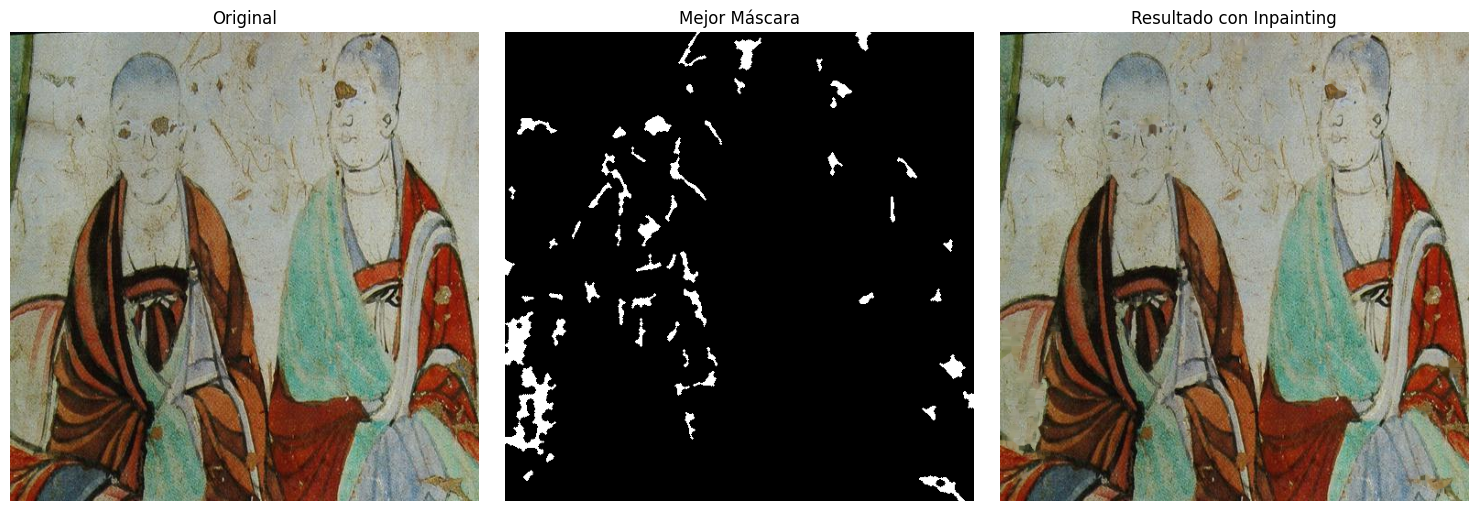

In [ ]:
inpaint_mask = (best_final_mask > 0).astype(np.uint8) * 255
inpainted_img = cv2.inpaint(img_original, inpaint_mask, inpaintRadius=0.5, flags=cv2.INPAINT_TELEA)
show_images(
            [img_original, best_final_mask, inpainted_img],
            ["Original", "Mejor Máscara", "Resultado con Inpainting"],
            [None, 'gray', None]
        )